In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [81]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))


In [87]:
kaggle_path = '/kaggle/input/diabetes-dataset/diabetes.csv'
local_path = 'diabetes1.csv'

if os.path.exists(kaggle_path):
    df = pd.read_csv(kaggle_path)
else:
    df = pd.read_csv(local_path)


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

In [6]:
df_list = df.columns.to_list()
df_list

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
df['Outcome'].unique()

array([1, 0])

In [10]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

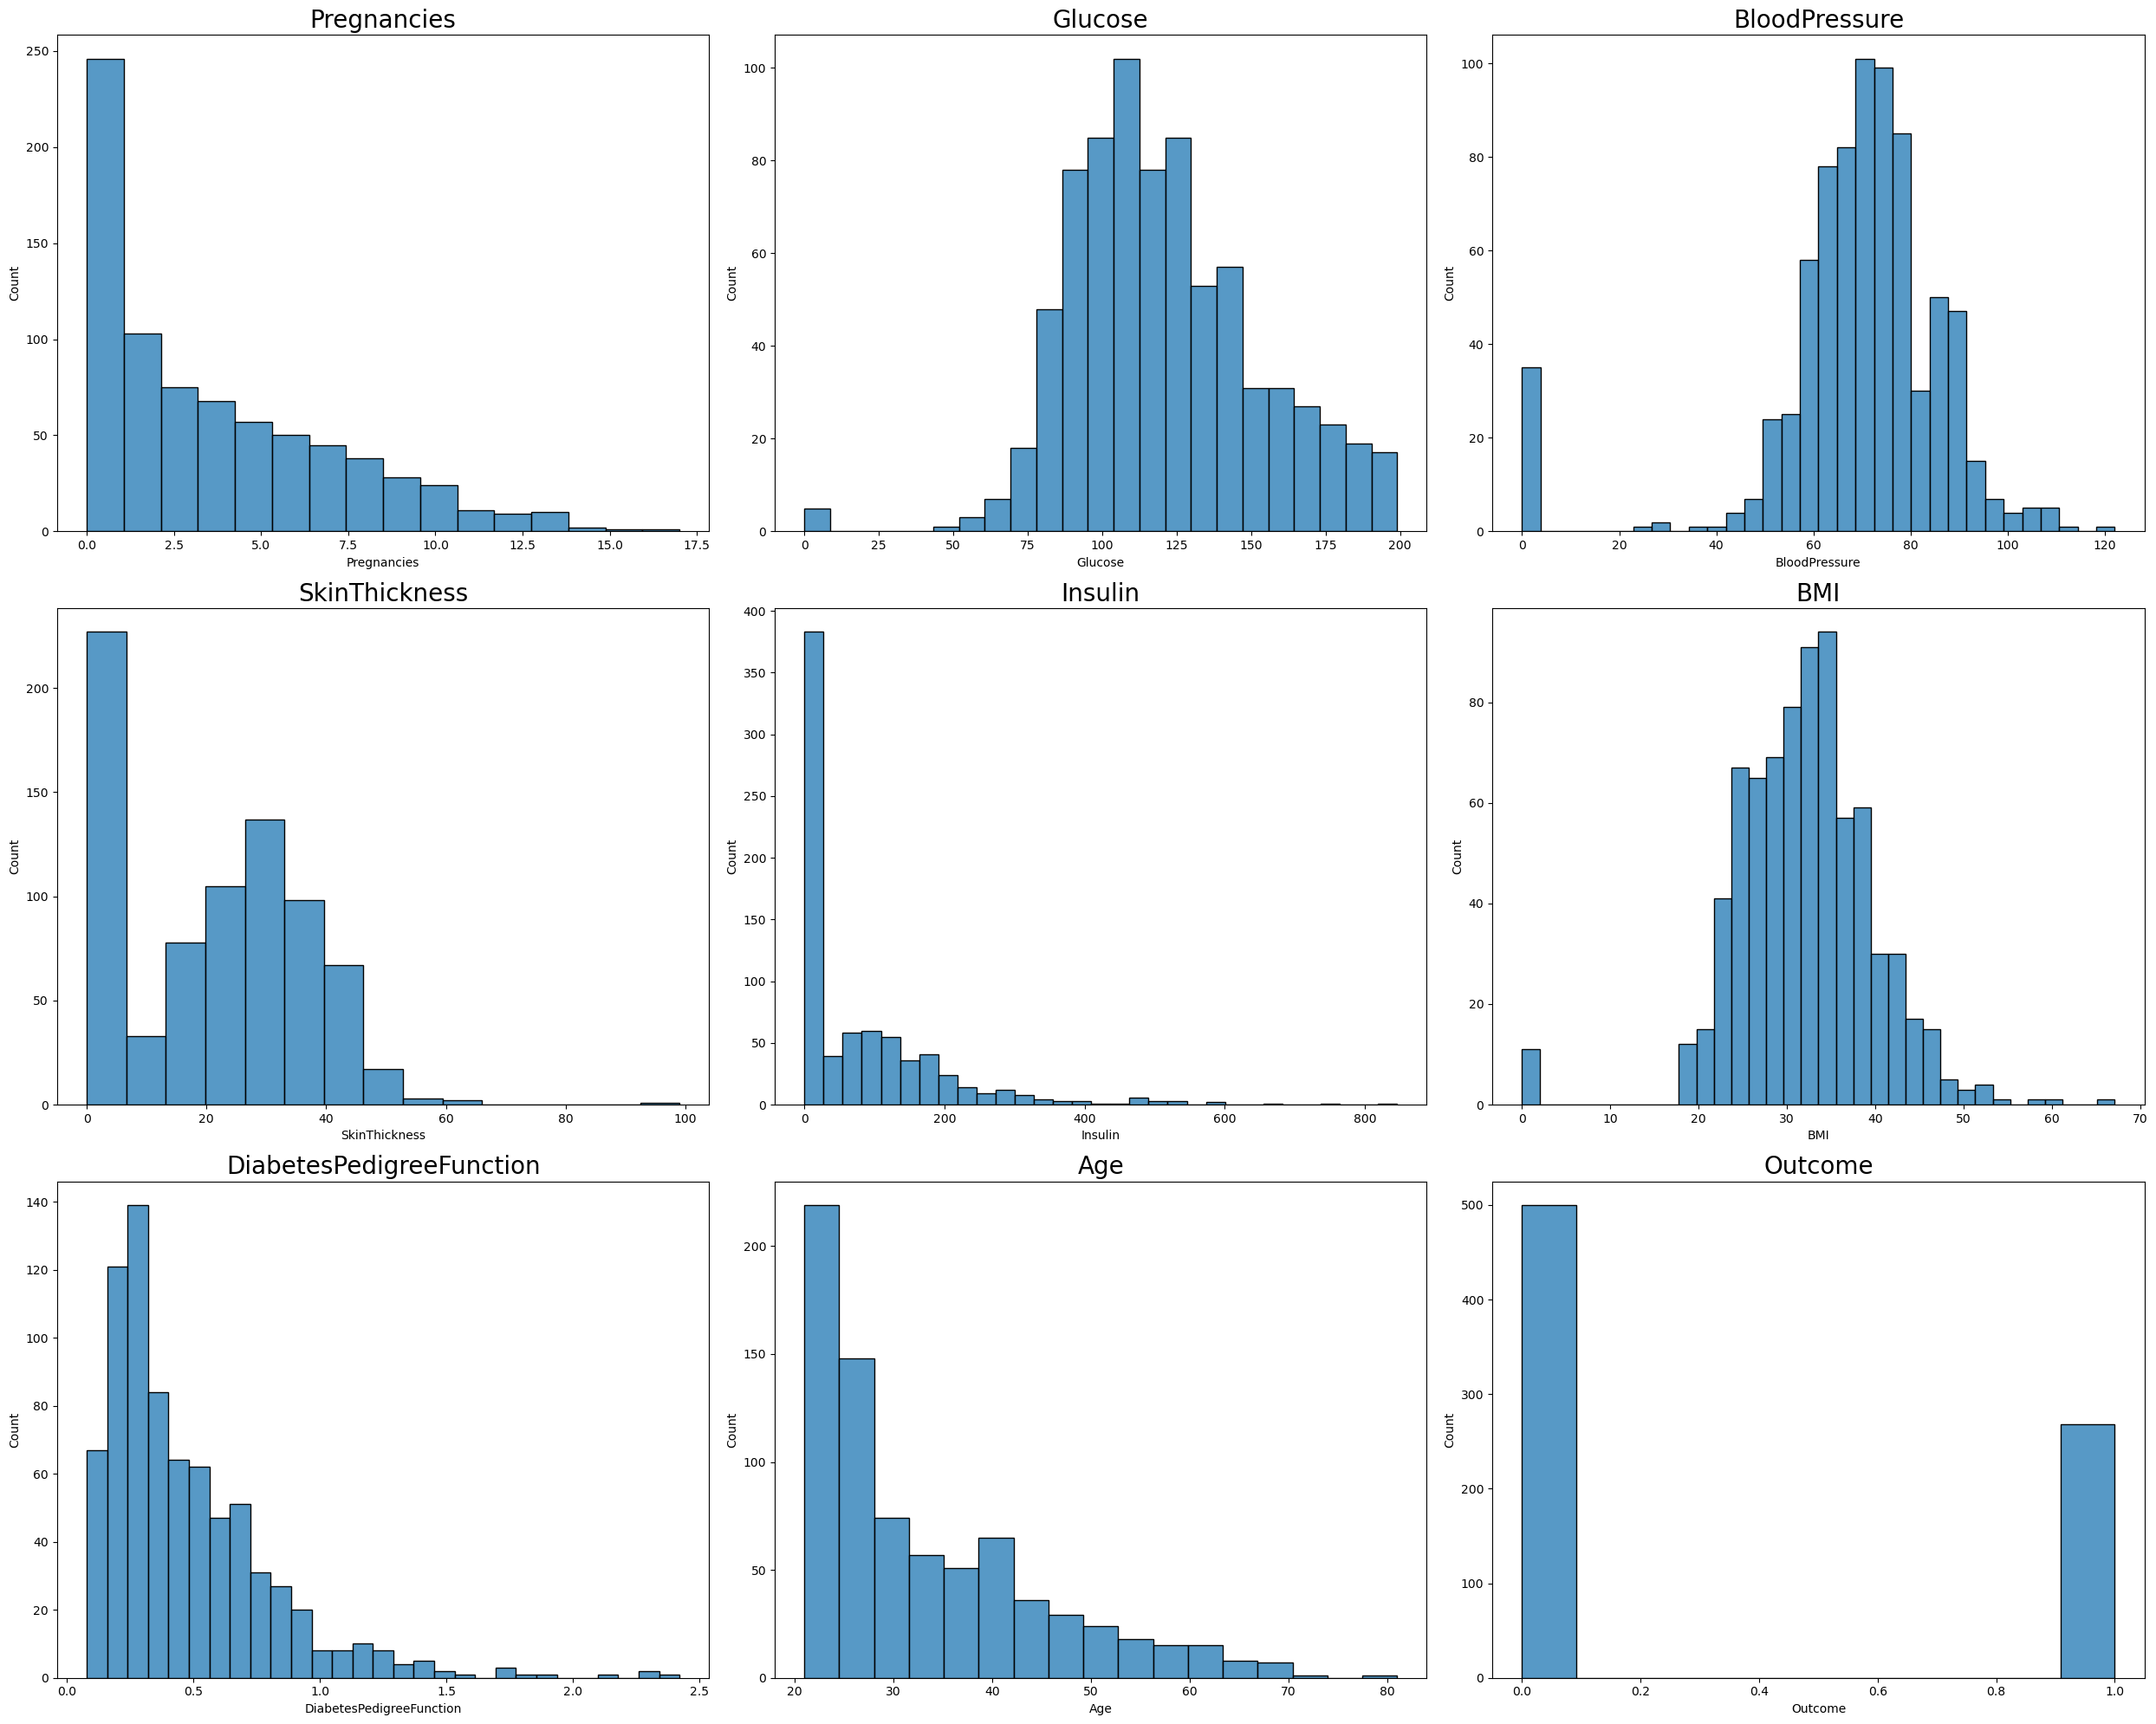

In [11]:
n =1
plt.figure(figsize=(25, 20))
for i in df:
    if n <= len(df_list):
        ax = plt.subplot(3, 3, n)
        sns.histplot(x= df[i])
        plt.title(i, fontsize= 20)
    n += 1
plt.tight_layout()

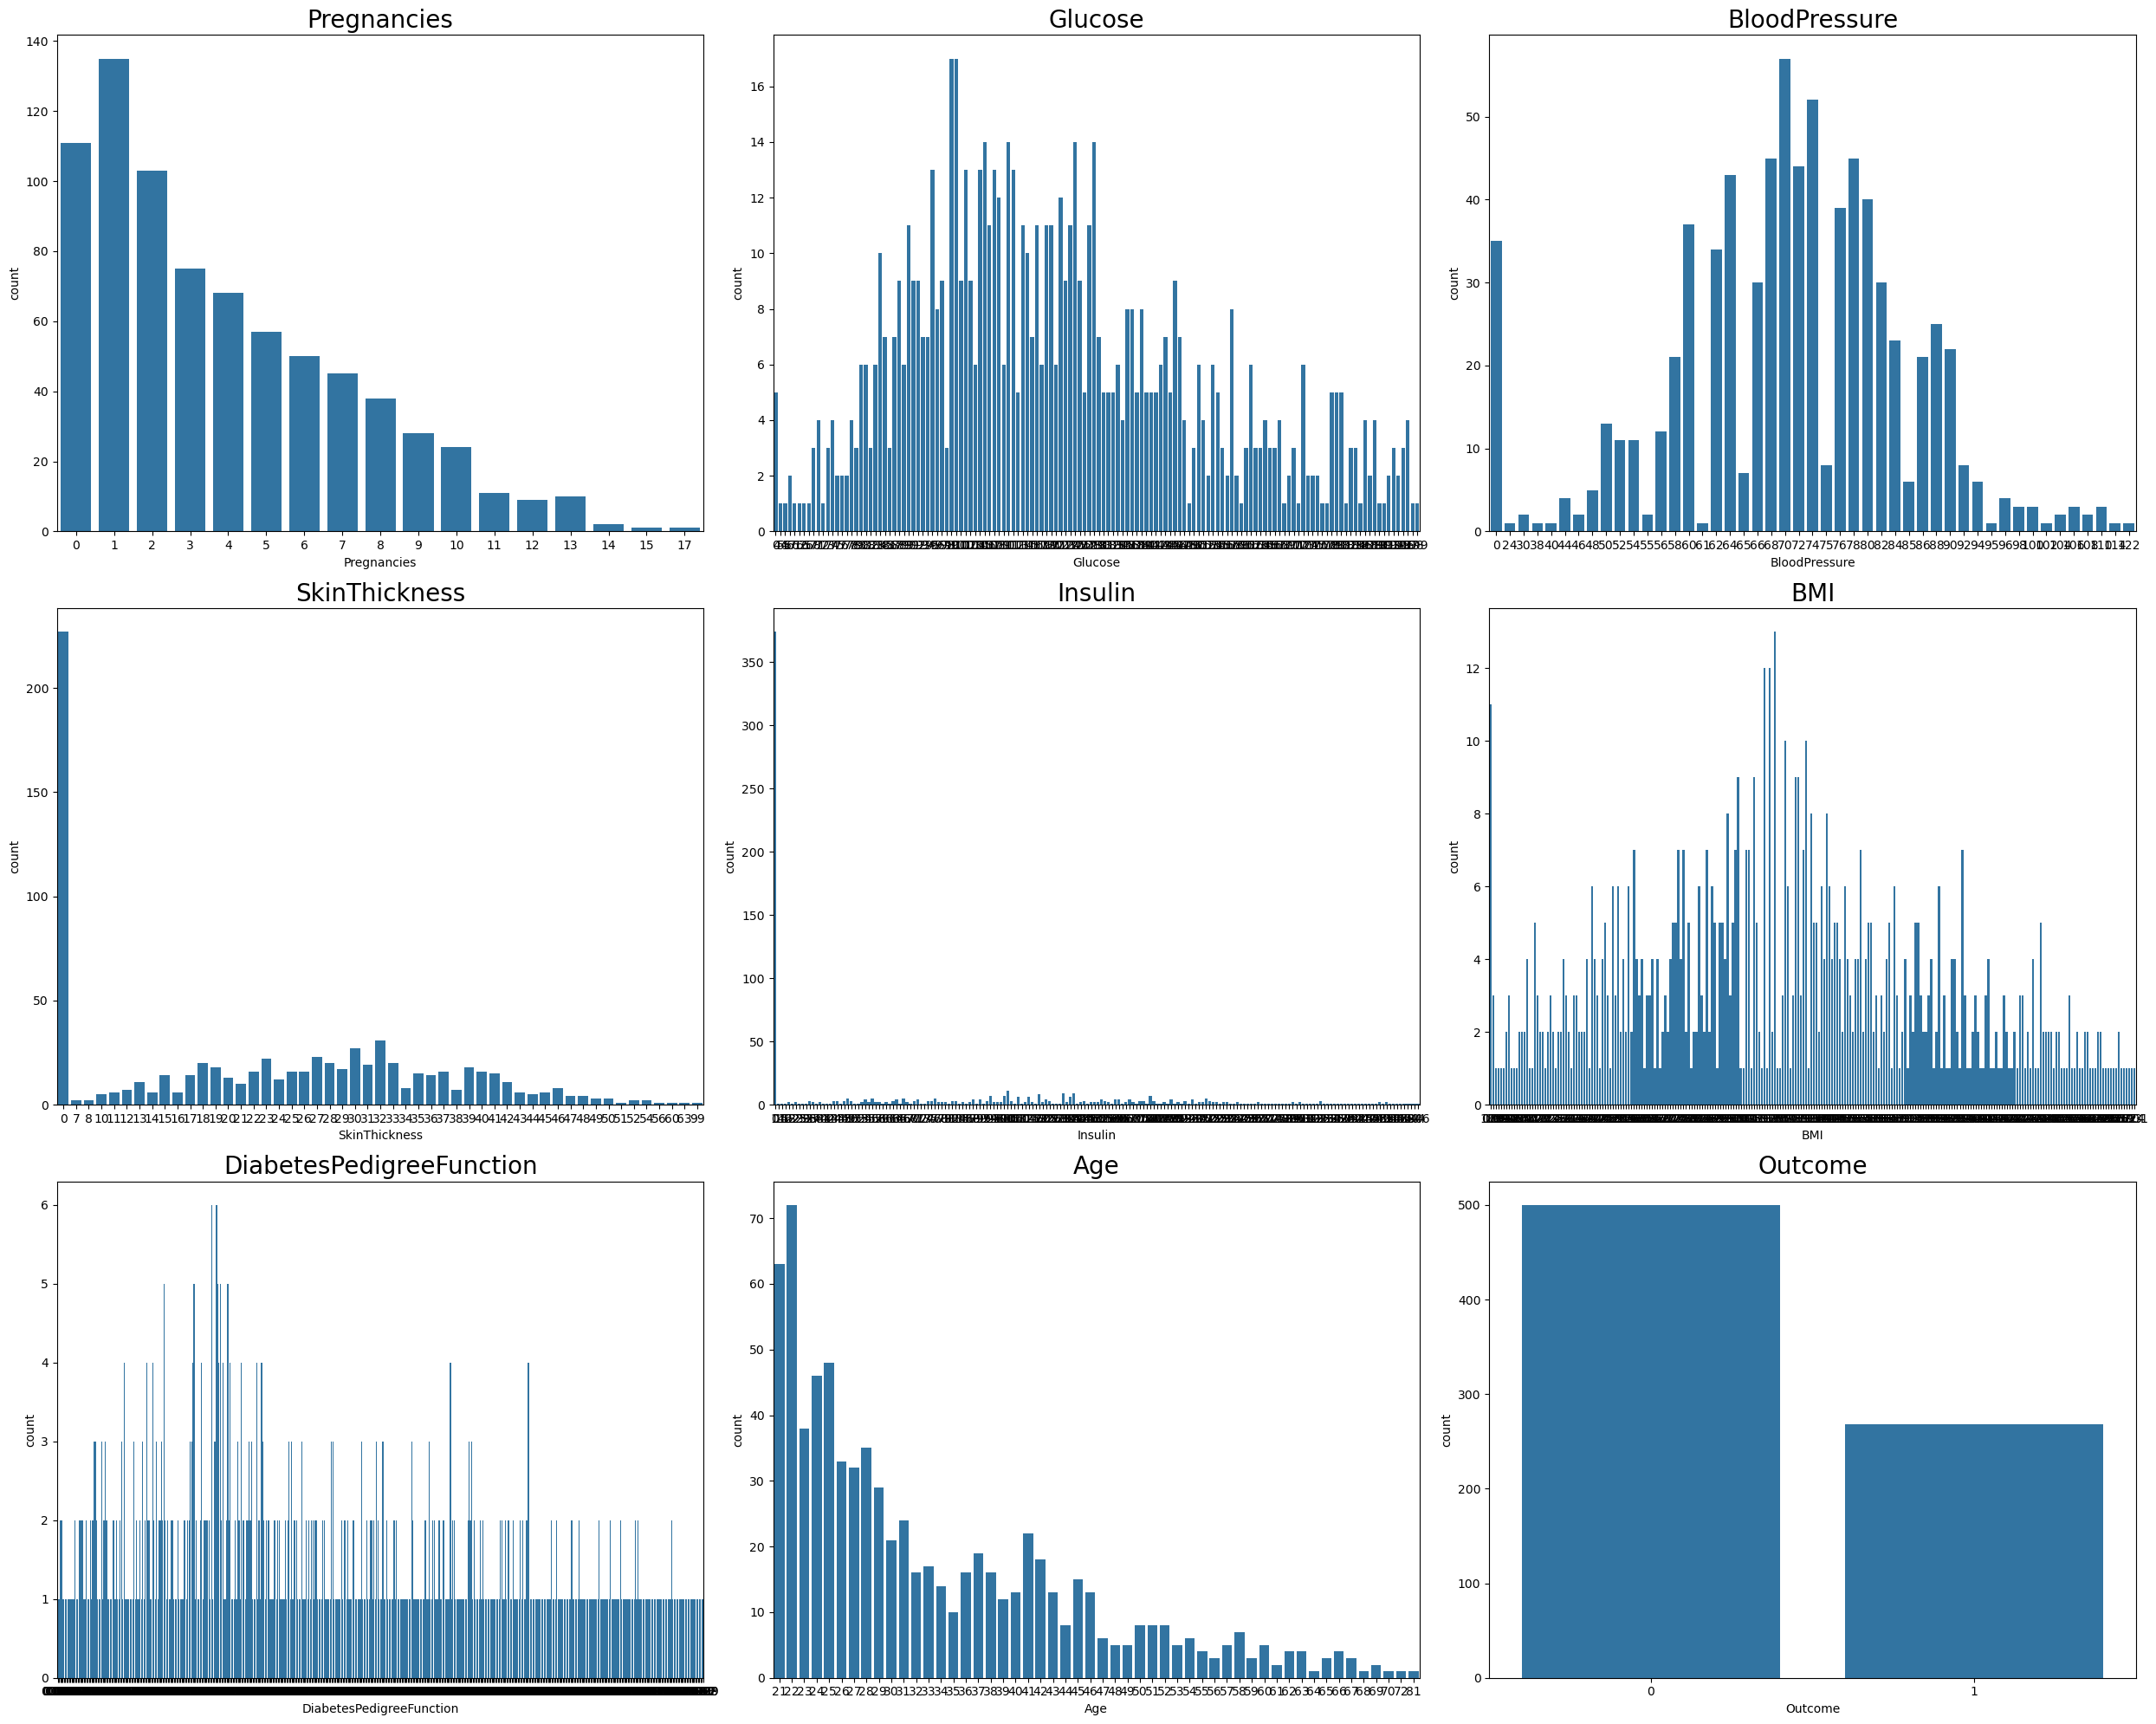

In [12]:
n = 1
plt.figure(figsize= (25, 20))
for i in df:
    if n <= len(df_list):
        ax = plt.subplot(3, 3, n)
        sns.countplot(data= df, x= i, ax = ax)
        plt.title(i, fontsize= 20)
    n += 1
plt.tight_layout()

## Conclusion
### Data looks corrpted as 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI' cannot be zero
### Clearly Data is imblanced by looking at total diabetic and non daibetic people from outcom


## Biveriate Analysis

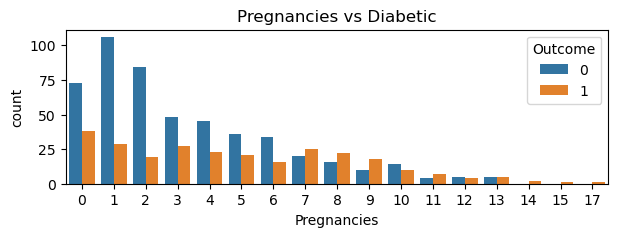

In [13]:
plt.figure(figsize=(7, 2))
sns.countplot(data= df, x = 'Pregnancies', hue='Outcome')
plt.title('Pregnancies vs Diabetic')
plt.show()

### Insights
#### If 'Pregnancies' are high then chance of having diabetes is low.
#### If 'Pregnancies' are low then chance of have diabetes is high.

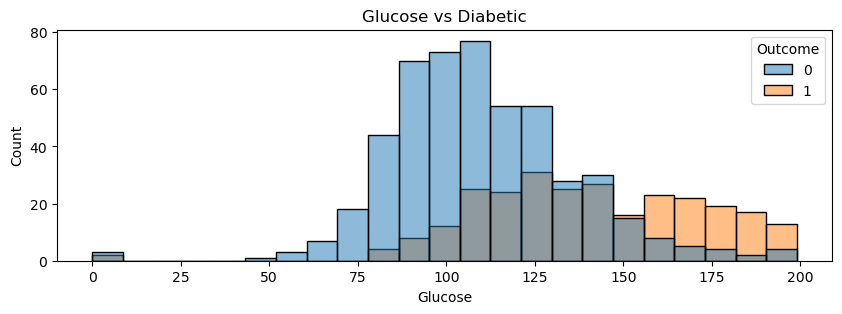

In [14]:
plt.figure(figsize=(10, 3))
sns.histplot(data= df, x = 'Glucose', hue='Outcome')
plt.title('Glucose vs Diabetic')
plt.show()

### Insights
#### If the glucose level is high then chance of have diabetics is high.
#### If the glucose level is low then chance of have diabetics is low.

In [15]:
df_list

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

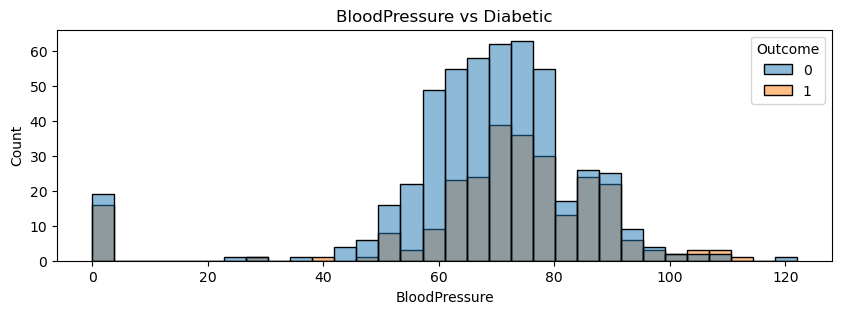

In [16]:
plt.figure(figsize=(10, 3))
sns.histplot(data= df, x = 'BloodPressure', hue='Outcome')
plt.title('BloodPressure vs Diabetic')
plt.show()

### Insights
#### If the BloodPressure level is high then chance of have diabetics is high.
#### If the BloodPressure level is low then chance of have diabetics is low.

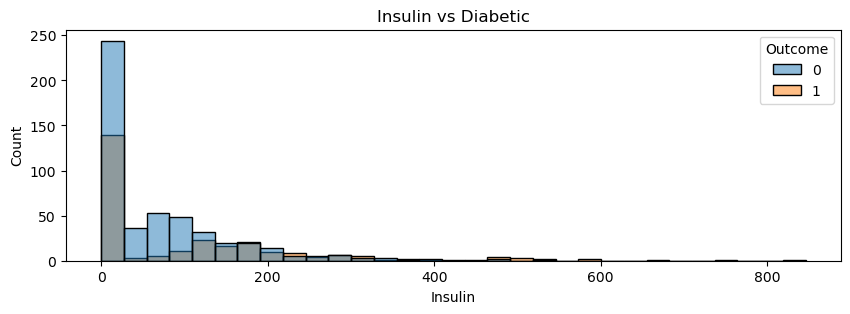

In [17]:
plt.figure(figsize=(10, 3))
sns.histplot(data= df, x = 'Insulin', hue='Outcome')
plt.title('Insulin vs Diabetic')
plt.show()

### Insights
#### If the Insulin level is high then chance of have diabetics is high.
#### If the Insulin level is low then chance of have diabetics is low.

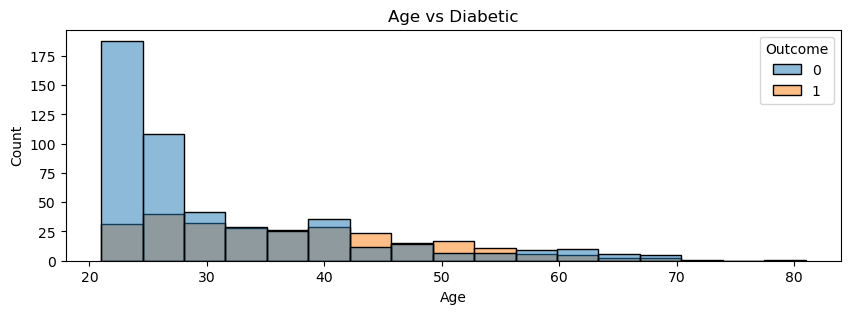

In [18]:
plt.figure(figsize=(10, 3))
sns.histplot(data= df, x = 'Age', hue='Outcome')
plt.title('Age vs Diabetic')
plt.show()

### Insights
#### If the Age level is high then chance of have diabetics is high.
#### If the Age level is low then chance of have diabetics is low.

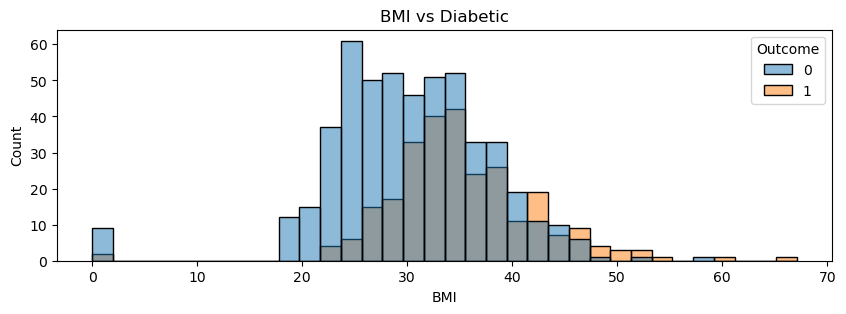

In [19]:
plt.figure(figsize=(10, 3))
sns.histplot(data= df, x = 'BMI', hue='Outcome')
plt.title('BMI vs Diabetic')
plt.show()

### Insights
#### If the BMI level is high then chance of have diabetics is high.
#### If the BMI level is low then chance of have diabetics is low.

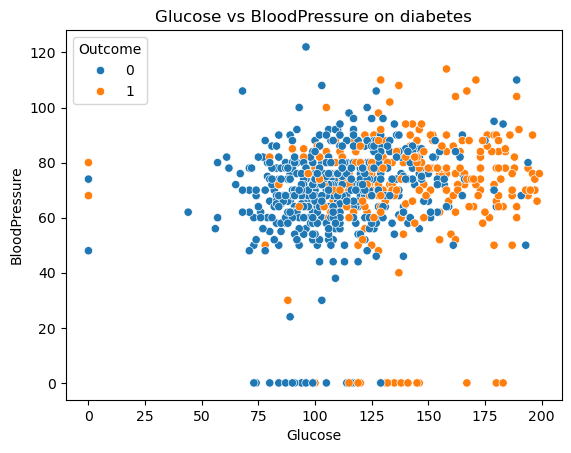

In [20]:
plt.figure()
sns.scatterplot(data= df, x= 'Glucose', y= 'BloodPressure', hue= 'Outcome')
plt.title('Glucose vs BloodPressure on diabetes')
plt.show()

### Insights
#### If the Glucose and Bloodpressure level is high then chance of have diabetics is high.
#### If the Glucose and Bloodpressure level is low then chance of have diabetics is low.

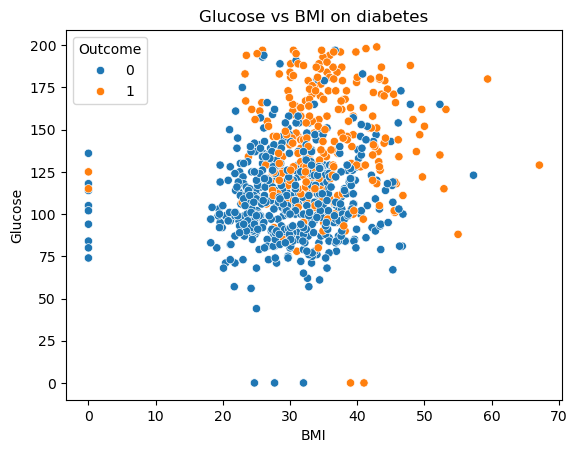

In [21]:
plt.figure()
sns.scatterplot(data= df, x= 'BMI', y= 'Glucose', hue= 'Outcome')
plt.title('Glucose vs BMI on diabetes')
plt.show()

### Insights
#### If the Glucose and BMI level is high then chance of have diabetics is high.
#### If the Glucose and BMI level is low then chance of have diabetics is low.

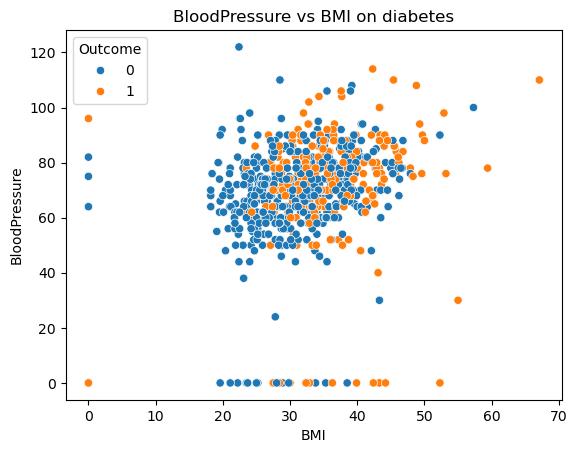

In [22]:
plt.figure()
sns.scatterplot(data= df, x= 'BMI', y= 'BloodPressure', hue= 'Outcome')
plt.title('BloodPressure vs BMI on diabetes')
plt.show()

### Insights
#### If the BMI and Bloodpressure level is high then chance of have diabetics is high.
#### If the BMI and Bloodpressure level is low then chance of have diabetics is low.

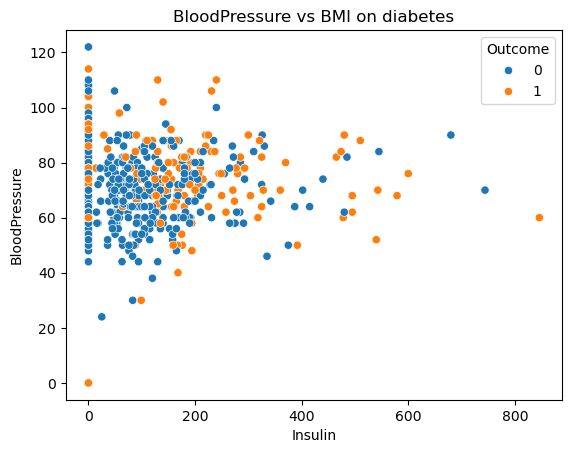

In [23]:
plt.figure()
sns.scatterplot(data= df, x= 'Insulin', y= 'BloodPressure', hue= 'Outcome')
plt.title('BloodPressure vs BMI on diabetes')
plt.show()

### Insights
#### If the Insulin and Bloodpressure level is high then chance of have diabetics is high.
#### If the Insulin and Bloodpressure level is low then chance of have diabetics is low.

## Multivarite Anaylsis

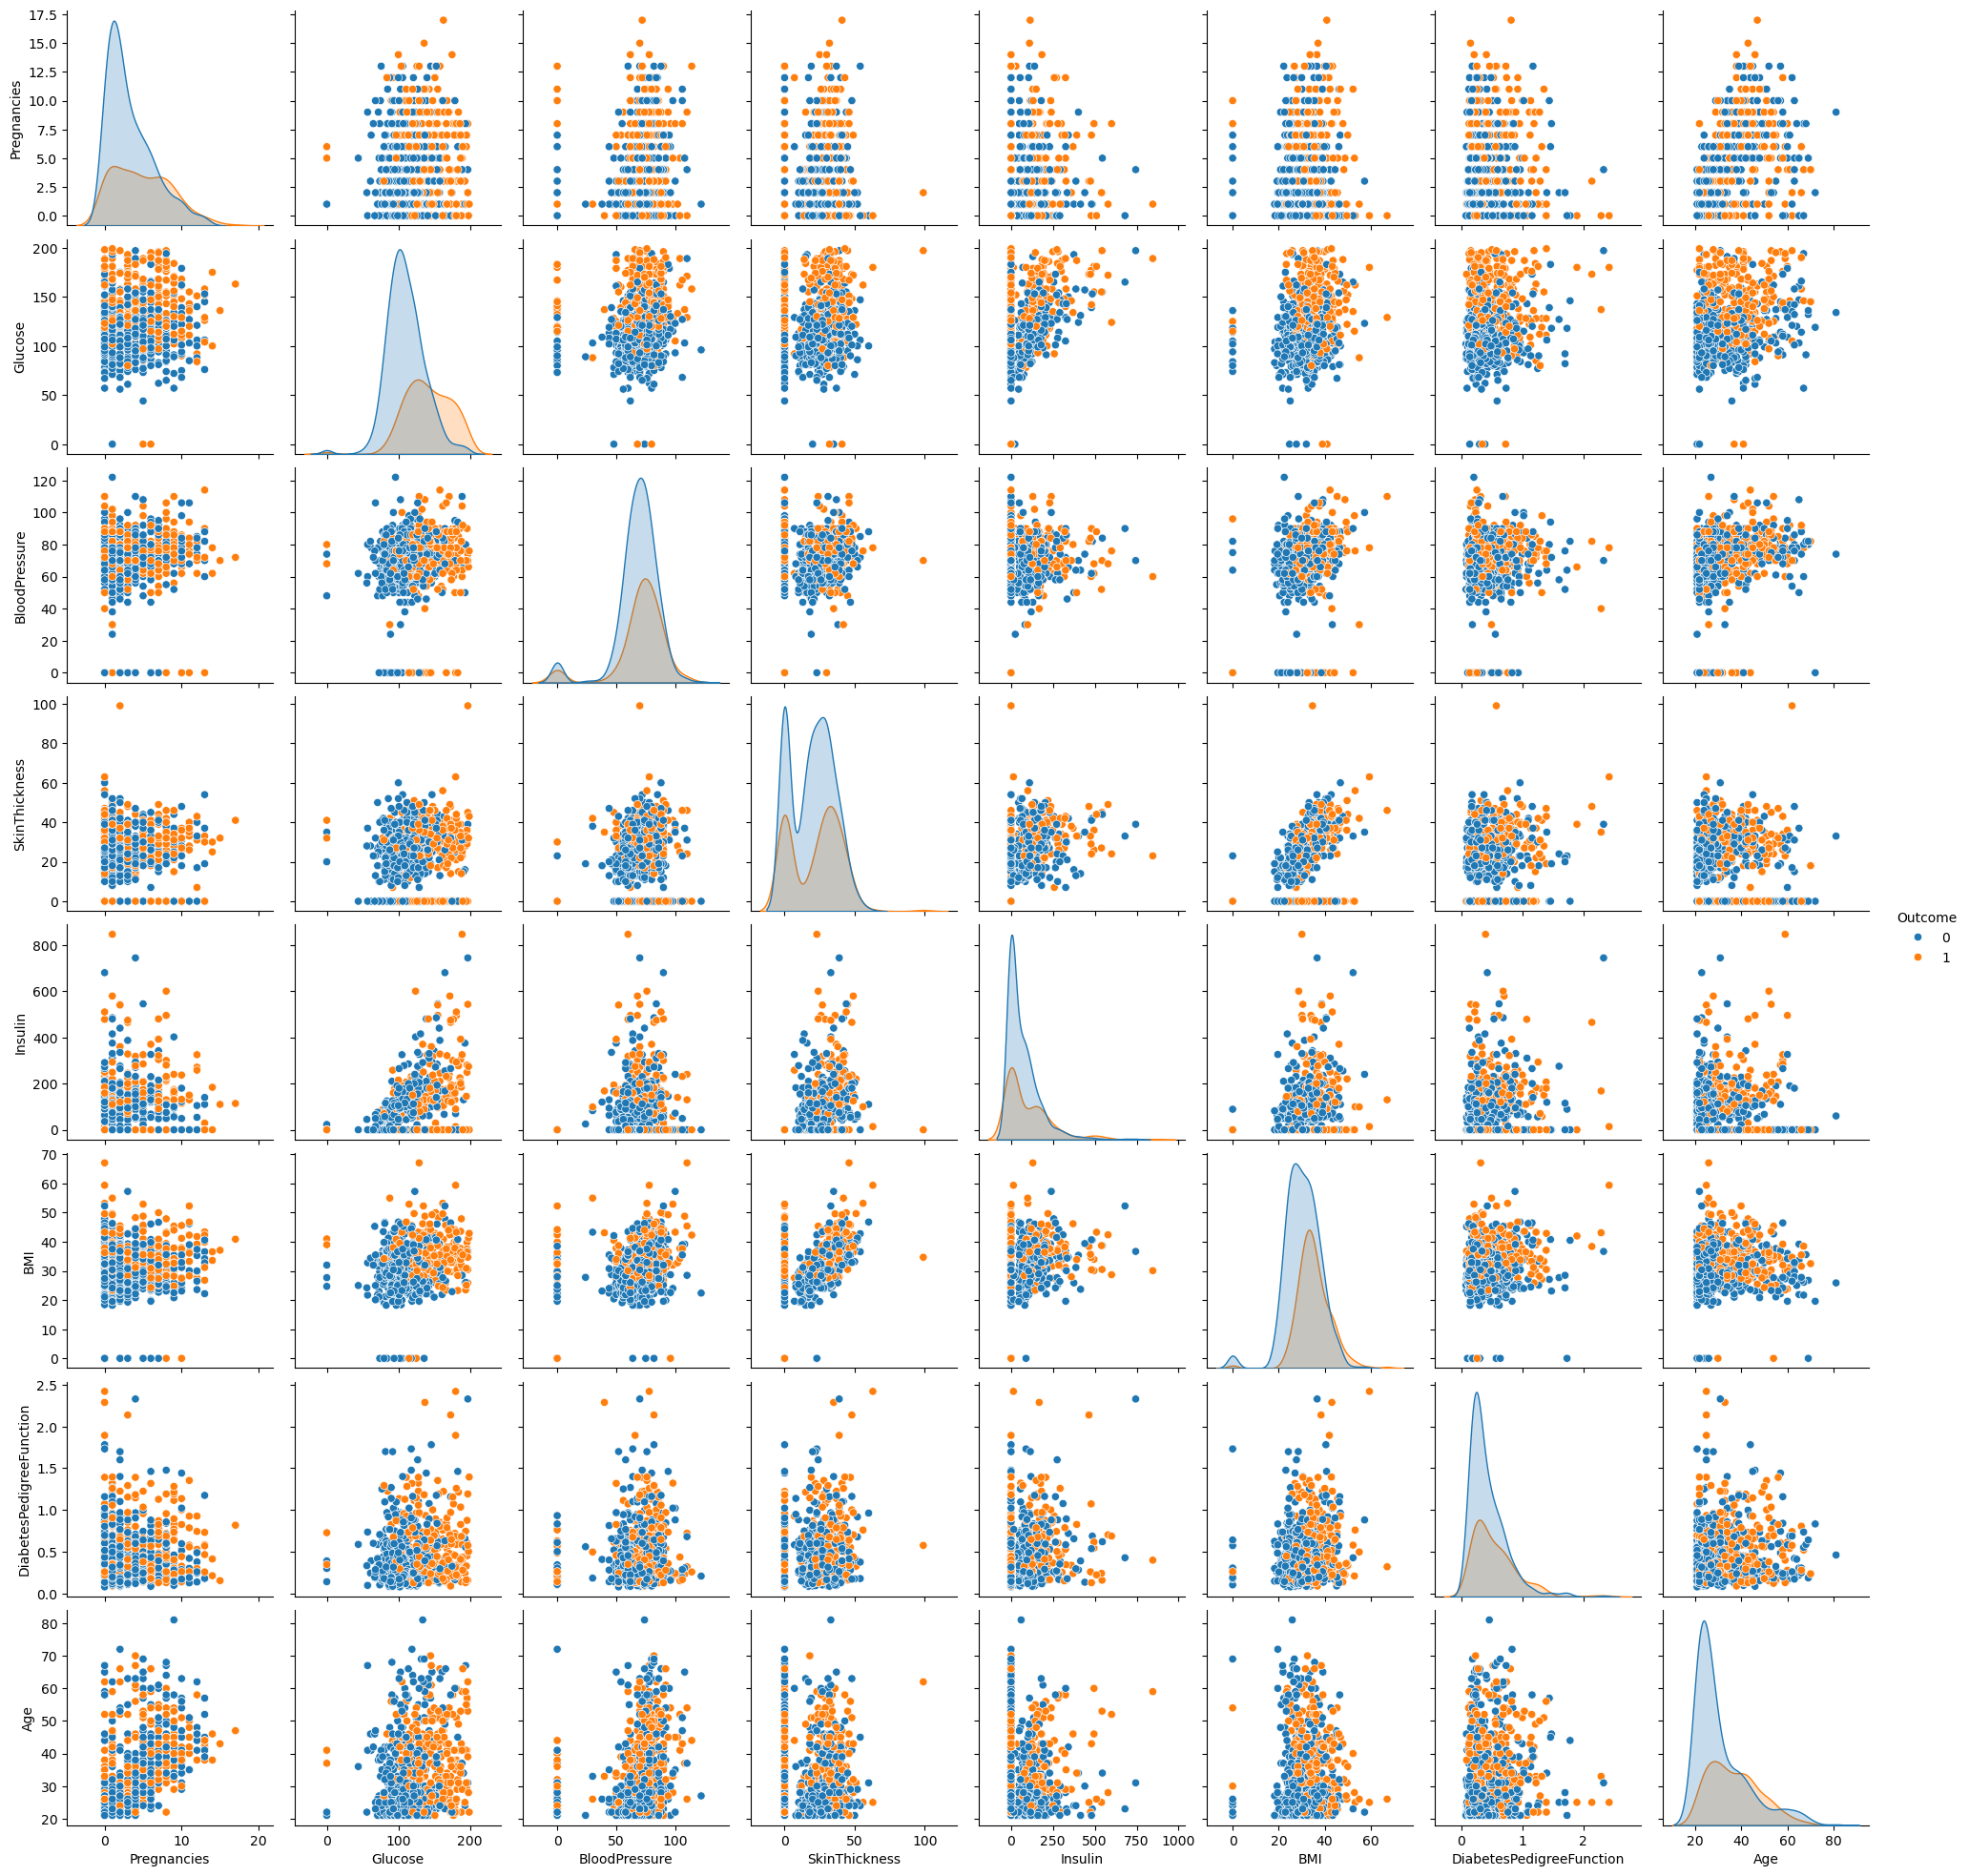

In [24]:
sns.pairplot(data= df, hue='Outcome')
plt.show()

## Data Preprocessing

In [25]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df_list

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [28]:
x = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for i in x:
    df[i] = df[i].replace(0, df[i].median())
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


In [29]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450911,6.875366,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


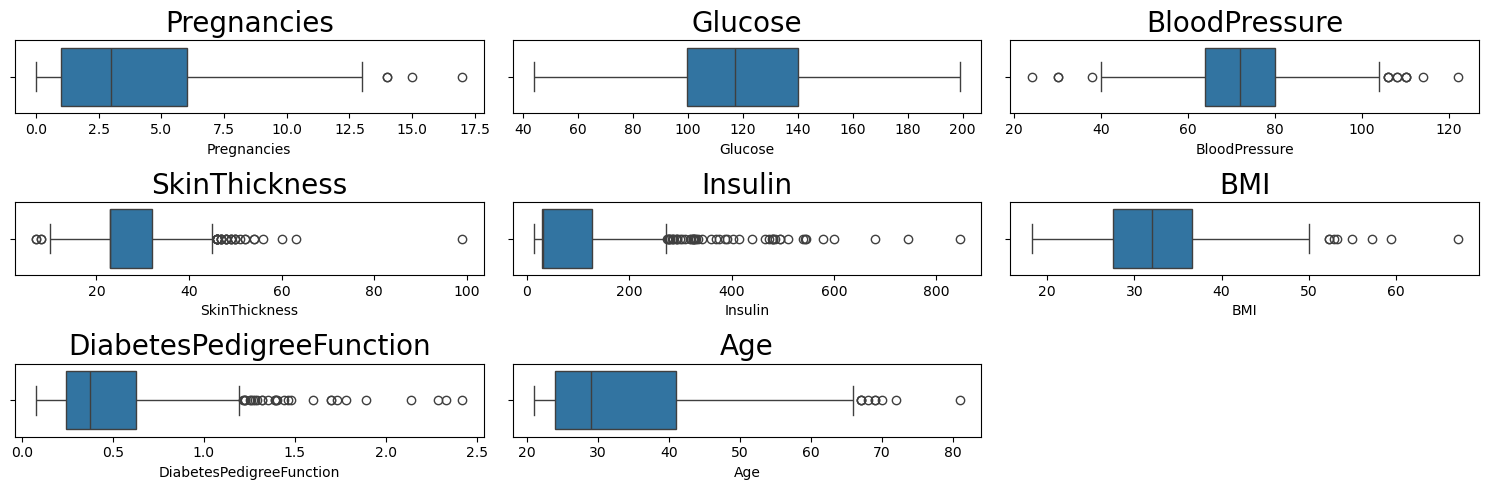

In [30]:
n = 1
plt.figure(figsize=(15, 5))
for i in df.drop(columns='Outcome'):
    if n <= len(df_list):
        ax = plt.subplot(3, 3, n)
        sns.boxplot(x= df[i])
        plt.title(i, fontsize= 20)
    n += 1
plt.tight_layout()

In [31]:
for i in df.drop(columns='Outcome'):
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out = df[(df[i] < lower) | (df[i] > upper)].index
    df = df.drop(out)

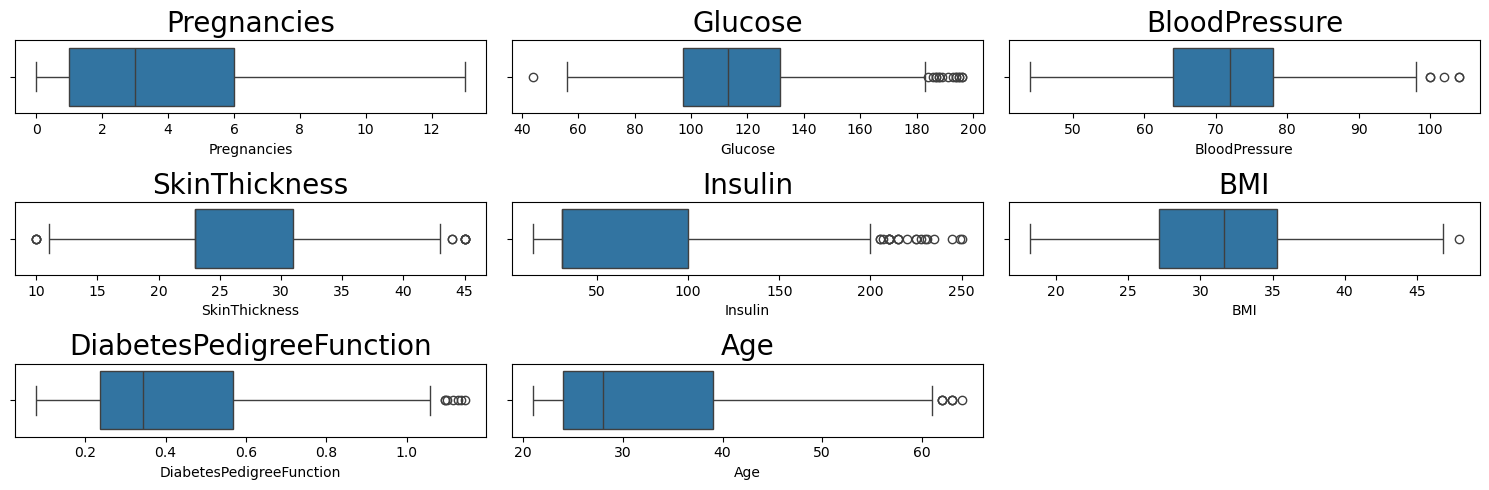

In [32]:
n = 1
plt.figure(figsize=(15, 5))
for i in df.drop(columns="Outcome"):
    if n <= len(df_list):
        ax = plt.subplot(3, 3, n)
        sns.boxplot(x= df[i])
        plt.title(i, fontsize= 20)
    n += 1
plt.tight_layout()

In [72]:
# scaling
from sklearn.preprocessing import  StandardScaler
scaling = StandardScaler()
non_scale = df[['Outcome']].reset_index(drop=True)
df1 = scaling.fit_transform(df.drop(['Outcome'], axis=1))
df2 = pd.DataFrame(df1, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
                                  'DiabetesPedigreeFunction', 'Age']).reset_index(drop=True)
df2
new_df = pd.concat([df2, non_scale], axis=1)
new_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.699244,1.100133,0.036926,1.219663,-0.696719,0.344582,0.900213,1.723647,1
1,-0.865658,-1.145397,-0.526116,0.409190,-0.696719,-0.804203,-0.268079,-0.102356,0
2,1.325205,2.347649,-0.713796,-0.401283,-0.696719,-1.345774,1.090695,-0.006251,1
3,-0.865658,-1.002823,-0.526116,-0.401283,0.438582,-0.558035,-1.046941,-1.063411,0
4,0.386264,-0.040454,0.224606,-0.401283,-0.696719,-0.968316,-0.903021,-0.198462,0
...,...,...,...,...,...,...,...,...,...
610,1.638185,-1.002823,-0.901477,-0.401283,-0.696719,-1.477064,-1.152765,0.089855,0
611,-0.552678,0.173406,-0.150755,0.139032,-0.696719,0.869742,-0.314642,-0.486778,0
612,0.386264,0.137763,0.036926,-0.401283,0.760399,-0.869848,-0.716771,-0.198462,0
613,-0.865658,0.315980,-1.089157,-0.401283,-0.696719,-0.229811,-0.276545,1.435331,1


## Feature Engineering

In [73]:
new_df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.135073,0.202885,0.108393,-0.110913,0.061023,-0.009576,0.577928,0.213108
Glucose,0.135073,1.000000,0.221493,0.073092,0.238423,0.165942,0.053441,0.266570,0.490232
BloodPressure,0.202885,0.221493,1.000000,0.119749,-0.065657,0.245195,0.010385,0.354814,0.165038
SkinThickness,0.108393,0.073092,0.119749,1.000000,0.249330,0.503749,0.127539,0.079836,0.149527
Insulin,-0.110913,0.238423,-0.065657,0.249330,1.000000,0.146603,0.210703,-0.078691,0.088799
BMI,0.061023,0.165942,0.245195,0.503749,0.146603,1.000000,0.165345,0.088503,0.280583
DiabetesPedigreeFunction,-0.009576,0.053441,0.010385,0.127539,0.210703,0.165345,1.000000,0.027806,0.175550
Age,0.577928,0.266570,0.354814,0.079836,-0.078691,0.088503,0.027806,1.000000,0.264015
Outcome,0.213108,0.490232,0.165038,0.149527,0.088799,0.280583,0.175550,0.264015,1.000000


<Axes: >

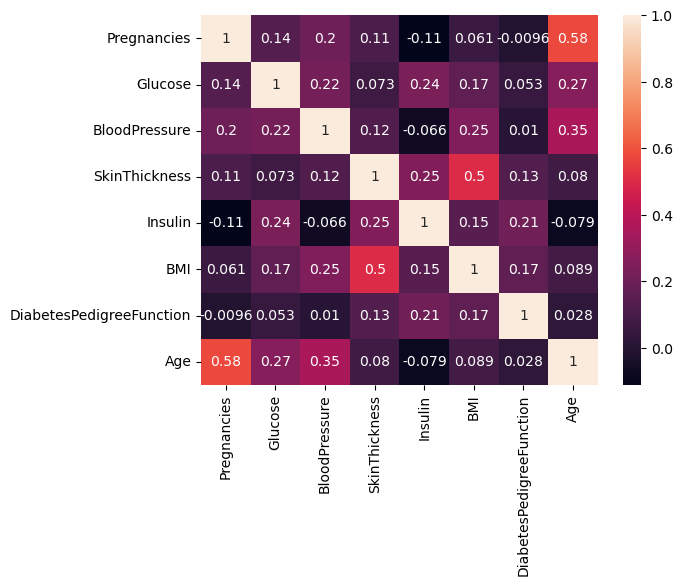

In [74]:
sns.heatmap(new_df.drop('Outcome', axis=1).corr(), annot=True)

## Model building

In [75]:
#spliting data to x and y
x = new_df.drop(columns="Outcome")
y = new_df['Outcome']

In [76]:
# Train test spliting
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [77]:
# importing model and training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, solver='liblinear', C=1.0)
model.fit(x_train, y_train)

LogisticRegression(max_iter=2000, solver='liblinear')

In [78]:
y_pred = model.predict(x_test)

df3 = pd.DataFrame({
    'y_true': y_test.reset_index(drop=True),
    'y_pred': y_pred
})
y_prob = model.predict_proba(x_test_scaled)[:, 1]
y_pred = (y_prob >= 0.45).astype(int)  # try 0.4, 0.45, 0.5

df3.head(10)

,y_true,y_pred
0,0,0
1,1,0
2,0,0
3,1,1
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,0


## Evaluation of the Model

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7567567567567568

Confusion Matrix:
 [[108  20]
 [ 25  32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83       128
           1       0.62      0.56      0.59        57

    accuracy                           0.76       185
   macro avg       0.71      0.70      0.71       185
weighted avg       0.75      0.76      0.75       185



## Model Evaluation Conclusion
### The final Logistic Regression model achieved an accuracy of 75.7% on the test set. Given the class imbalance in the dataset, evaluation focused on recall and F1-score for the positive (diabetic) class. The model attained a recall of 0.56 and an F1-score of 0.59 for the positive class, indicating a balanced trade-off between identifying diabetic cases and limiting false positives. This configuration was selected as the final model due to its improved sensitivity compared to more conservative configurations, while maintaining reasonable overall accuracy.